In [1]:
!wget -O "Dataset.zip" "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded"
!unzip Dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (132).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1320).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1321).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1322).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1323).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1324).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1325).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1326).JPG  
  infl

In [2]:
!pip install -q tensorflow split-folders

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import splitfolders

In [3]:
splitfolders.ratio(
    '/content/Plant_leave_diseases_dataset_with_augmentation',
    output="dataset",
    seed=1337,
    ratio=(.8, .1, .1)
)

Copying files: 61486 files [00:17, 3614.74 files/s]


In [4]:
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"
test_dir = "/content/dataset/test"

BATCH_SIZE = 32
IMG_SIZE = (128, 128)   # smaller = faster

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

class_names = train_dataset.class_names

Found 49179 files belonging to 39 classes.
Found 6139 files belonging to 39 classes.
Found 6168 files belonging to 39 classes.


In [5]:
# Use SMALL subset for fast training
train_dataset = train_dataset.take(300)
val_dataset = val_dataset.take(100)

# Cache + prefetch (speed boost)
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

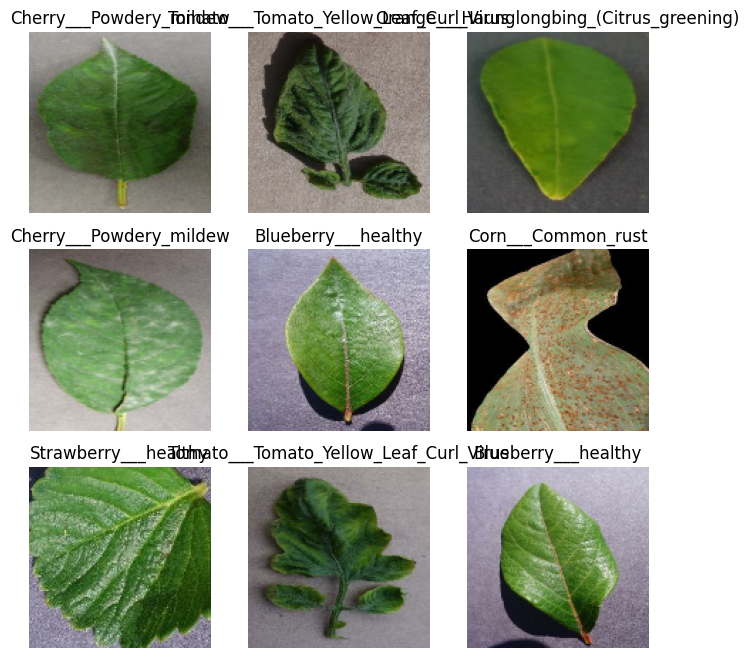

In [6]:
plt.figure(figsize=(8, 8))
for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [7]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

IMG_SHAPE = IMG_SIZE + (3,)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

prediction_layer = tf.keras.layers.Dense(39, activation='softmax')  # FIXED

inputs = tf.keras.Input(shape=(128, 128, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)

model = tf.keras.Model(inputs, outputs)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [10]:
initial_epochs = 2

history = model.fit(
    train_dataset,
    epochs=initial_epochs,
    validation_data=val_dataset
)

Epoch 1/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 38s 66ms/step - accuracy: 0.7203 - loss: 1.0299 - val_accuracy: 0.8828 - val_loss: 0.4282
Epoch 2/2
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9065 - loss: 0.3337 - val_accuracy: 0.9078 - val_loss: 0.3121


In [11]:
base_model.trainable = True

# Freeze most layers
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

fine_tune_epochs = 2

history_fine = model.fit(
    train_dataset,
    epochs=initial_epochs + fine_tune_epochs,
    initial_epoch=history.epoch[-1],
    validation_data=val_dataset
)

Epoch 2/4
300/300 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.4822 - loss: 2.0624 - val_accuracy: 0.8722 - val_loss: 0.4148
Epoch 3/4
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8273 - loss: 0.5725 - val_accuracy: 0.8897 - val_loss: 0.3534
Epoch 4/4
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9068 - loss: 0.3301 - val_accuracy: 0.9094 - val_loss: 0.2840


In [12]:
loss, accuracy = model.evaluate(test_dataset)
print("Test accuracy:", accuracy)

193/193 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.9100 - loss: 0.2759
Test accuracy: 0.9100194573402405


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


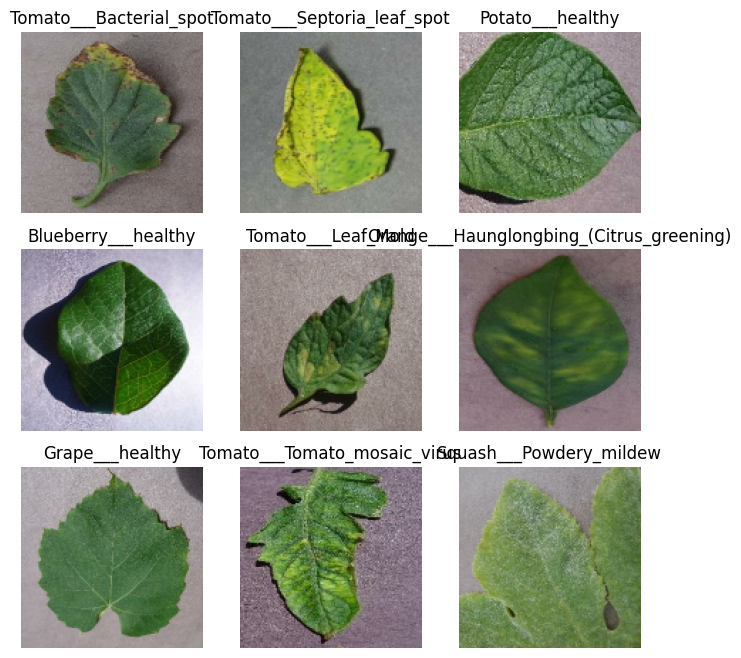

In [13]:
image_batch, label_batch = next(iter(test_dataset))

predictions = model.predict(image_batch)
predicted_classes = tf.argmax(predictions, axis=1)

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[predicted_classes[i]])
    plt.axis("off")

In [19]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_names))

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.97      0.72      0.83       100
                            Apple___Black_rot       0.94      0.94      0.94       100
                     Apple___Cedar_apple_rust       0.98      0.97      0.97       100
                              Apple___healthy       0.94      0.92      0.93       165
                    Background_without_leaves       0.75      1.00      0.86       115
                          Blueberry___healthy       0.97      0.99      0.98       151
                      Cherry___Powdery_mildew       0.95      0.96      0.96       106
                             Cherry___healthy       0.96      0.90      0.93       100
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.88      0.86      0.87       100
                           Corn___Common_rust       1.00      0.98      0.99       120
                  Corn___Northern_Leaf_Bli

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/ste

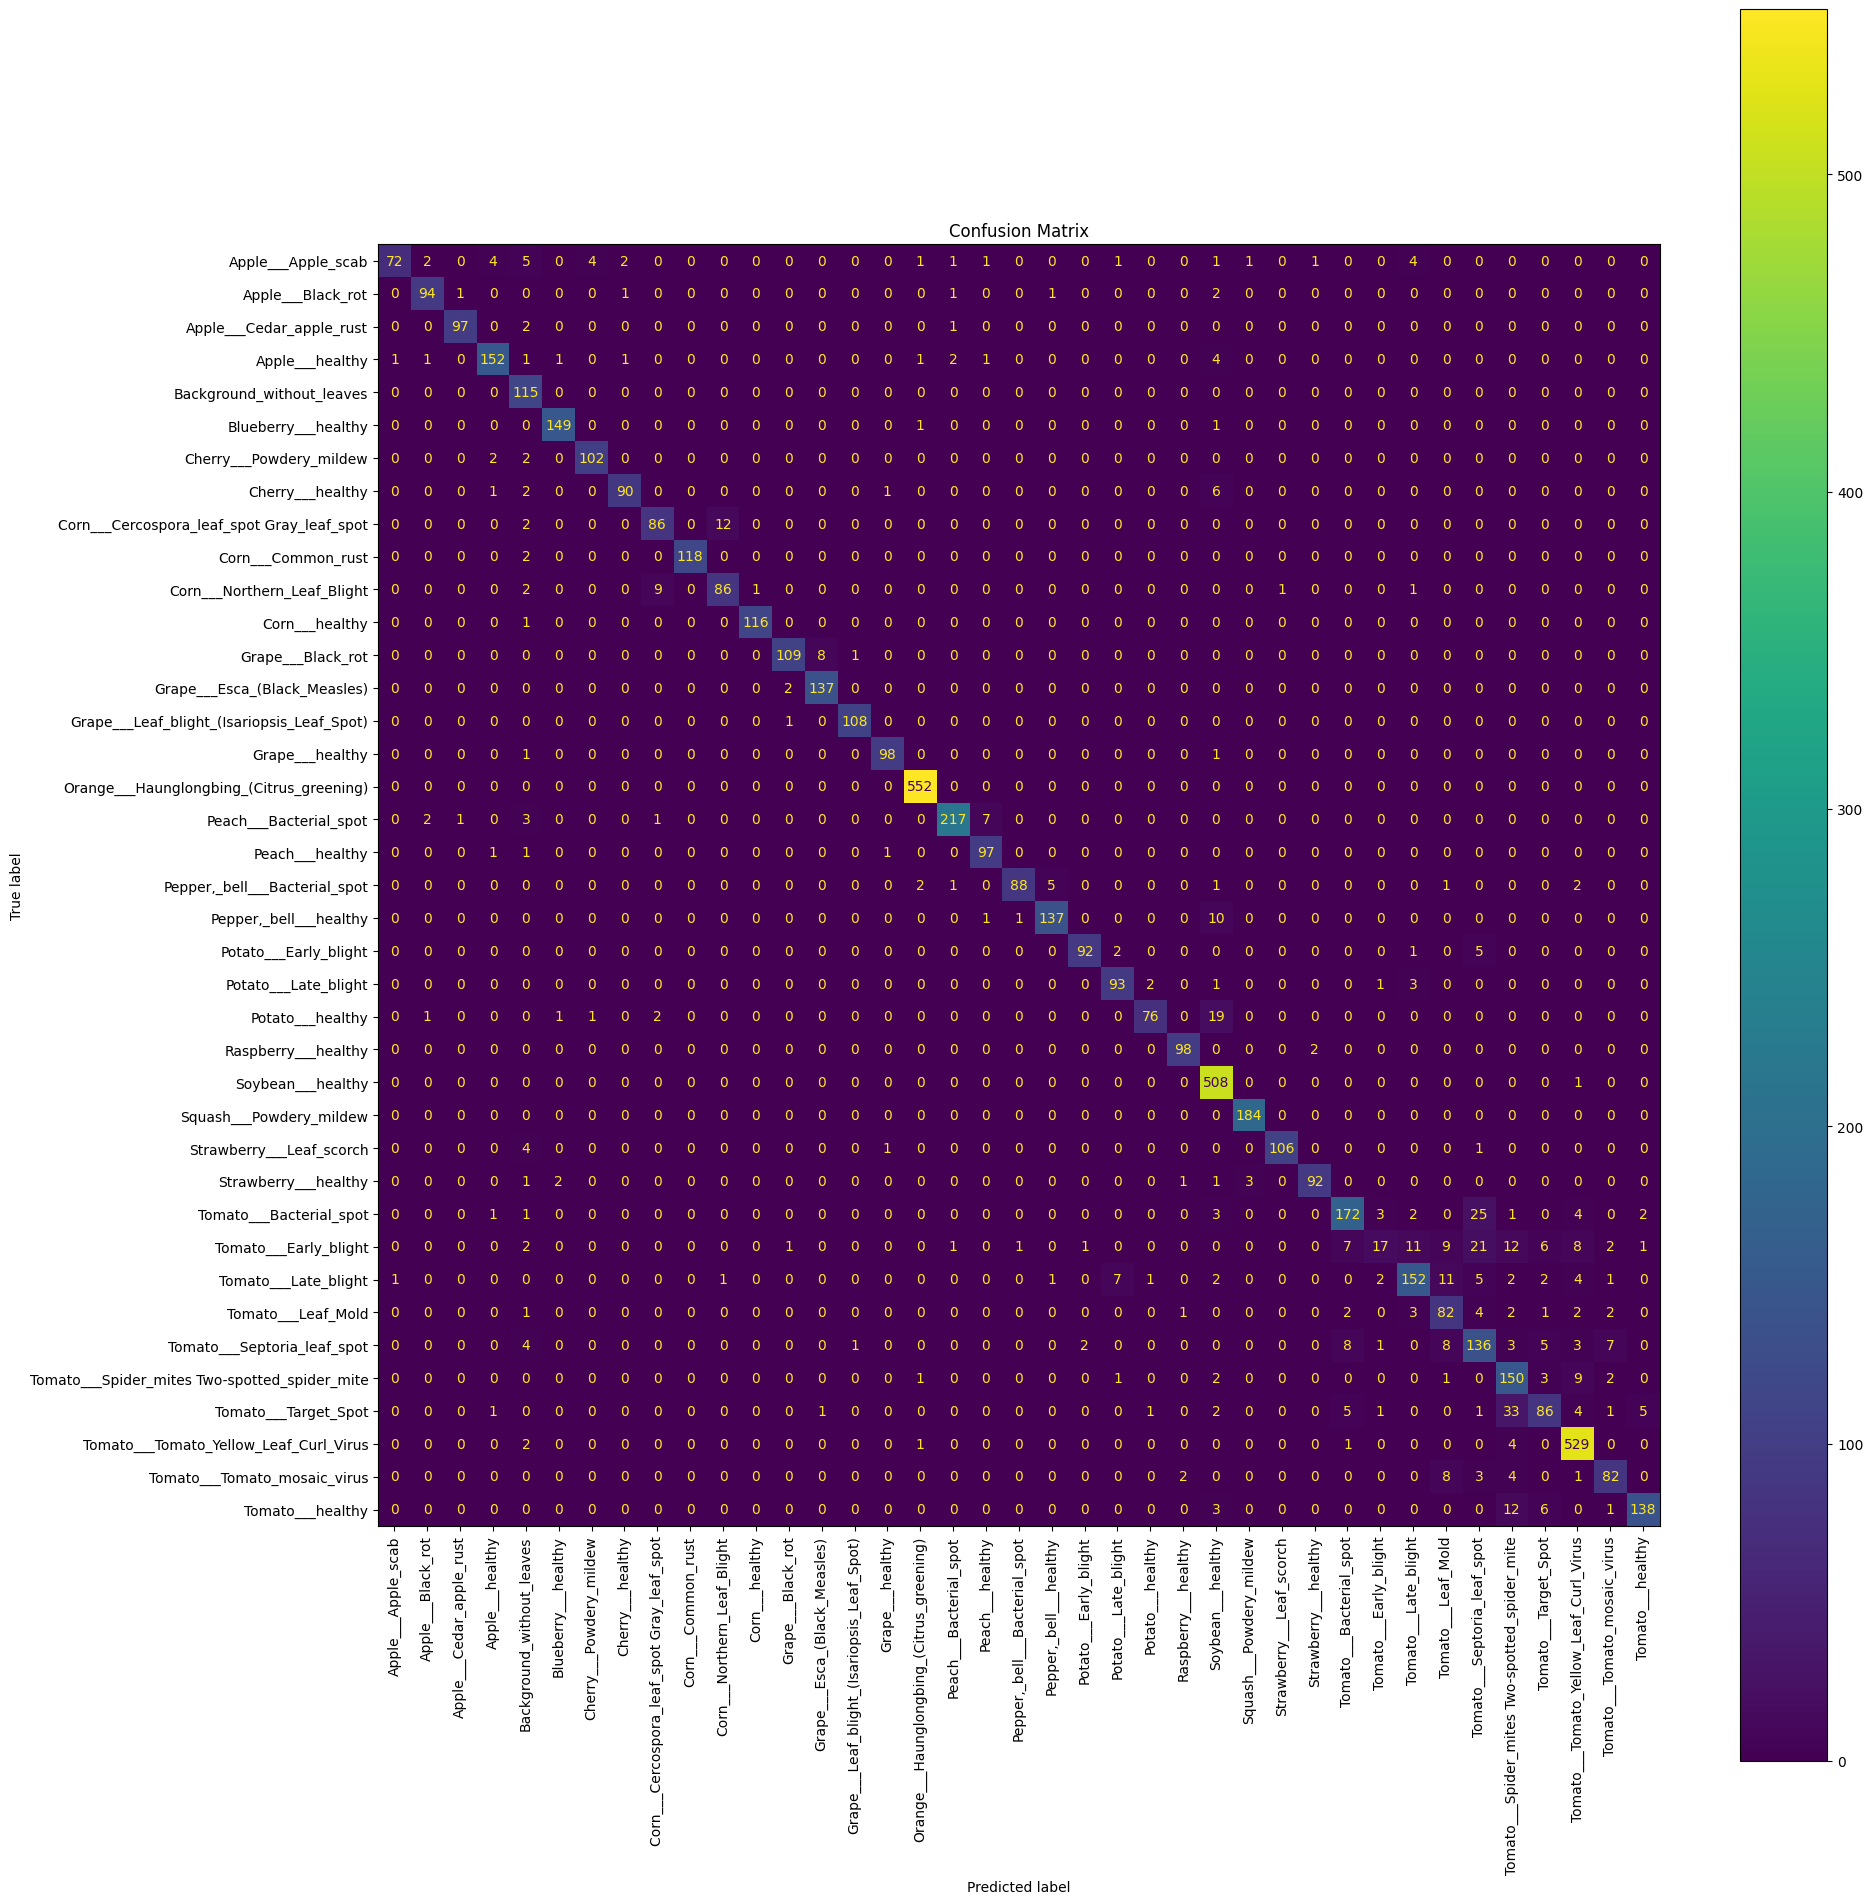

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 20))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=90, ax=plt.gca())
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


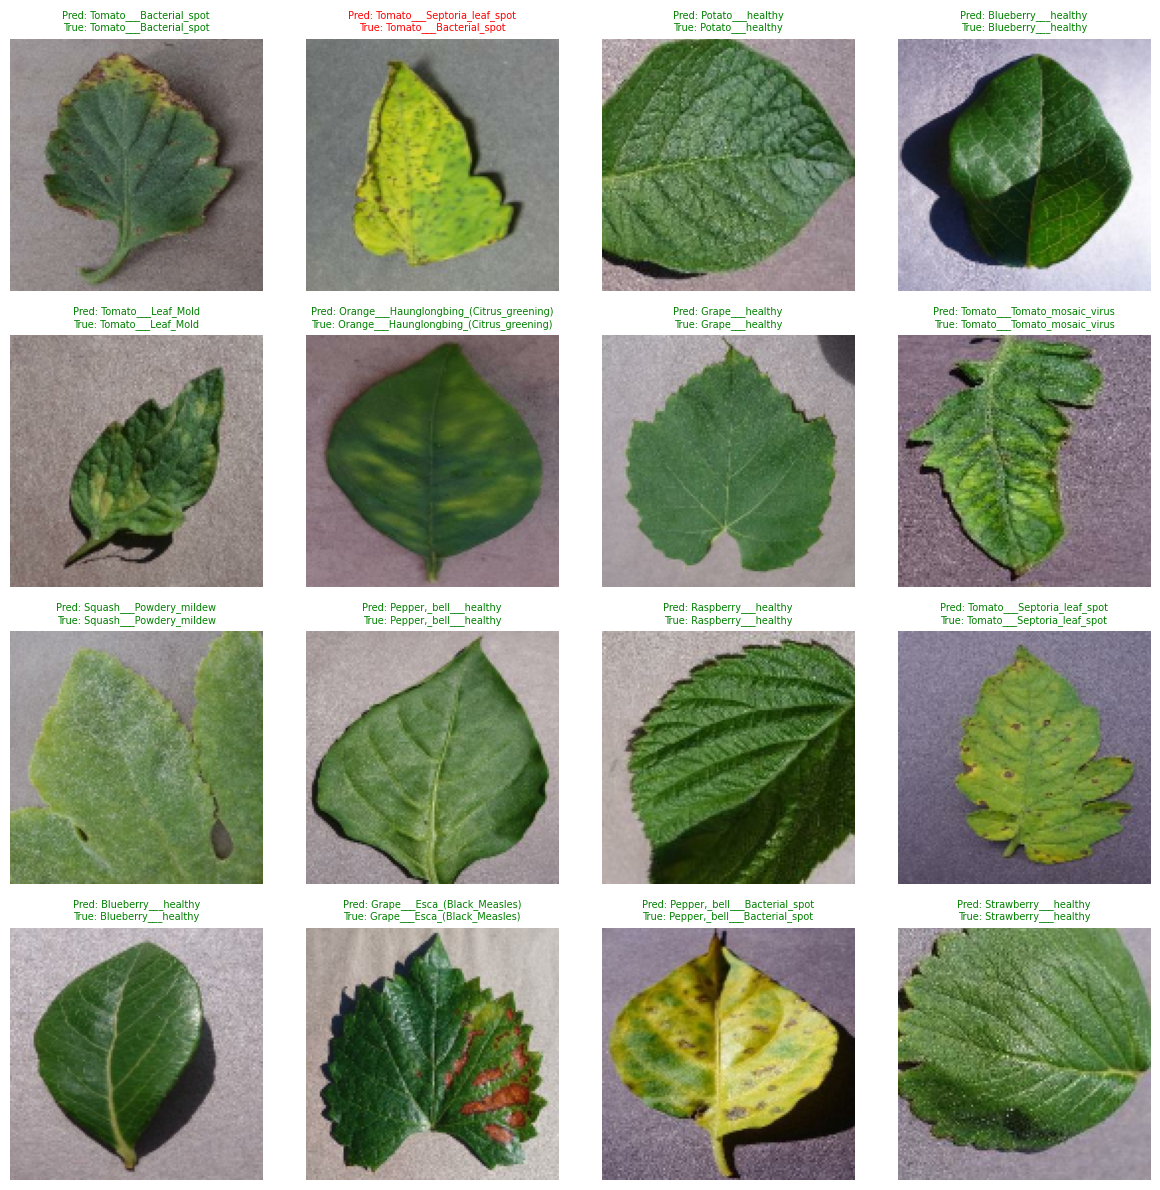

In [20]:
plt.figure(figsize=(12, 12))
for images, labels in test_dataset.take(1):
    preds = model.predict(images)
    for i in range(16):
        plt.subplot(4, 4, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true = class_names[labels[i]]
        pred = class_names[np.argmax(preds[i])]
        color = "green" if true == pred else "red"
        plt.title(f"Pred: {pred}\nTrue: {true}", color=color, fontsize=7)
        plt.axis("off")
plt.tight_layout()
plt.show()

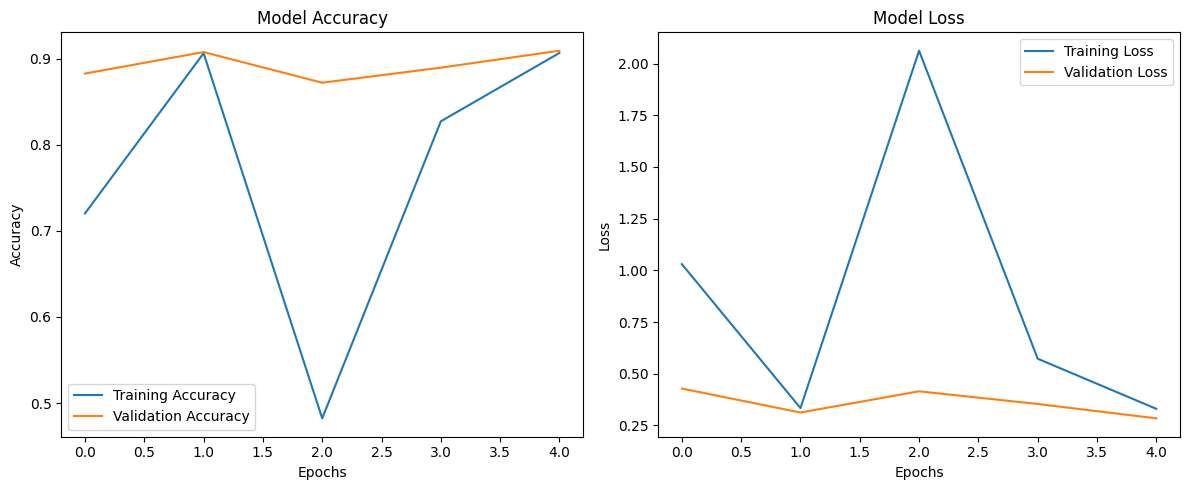

In [17]:
import matplotlib.pyplot as plt

# Accuracy
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

# Loss - fix: use history_fine for val_loss only if lengths match
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Make sure all same length
min_len = min(len(acc), len(val_acc), len(loss), len(val_loss))
acc = acc[:min_len]
val_acc = val_acc[:min_len]
loss = loss[:min_len]
val_loss = val_loss[:min_len]

epochs_range = range(min_len)

plt.figure(figsize=(12, 5))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
model.save("plant_disease_model.keras")
import json
with open("class_names.json", "w") as f:
  json.dump(class_names, f)
print("Saved!")

Saved!
